#### VENUS MAGNIFICATION CALCULATOR



This notebook computes magnifications $\mu$, magnification components ($\mu_{\rm tan}$, $\mu_{\rm rad}$), the $\mu_{\rm tan}$ orientation $\theta$ (east of north), deflection angles and source-plane positions from the best-fit lens model 

If lens model sample maps (gamma1, gamma2, kappa and deflection maps) are available, it also computes the 16th, 50th and 84th percentile of the quantities above.




#### Instructions: 

Define the input source **ids**, coordinates **ras**,**decs** and redshifts **zs** by running one of the input cells (by providing either a single source, lists with several sources or path to the fits table with keywords for each column). You can also change the coordinate system **frame** in which the ra,dec coordinate are given. Then, choose the lens model by setting **clustermodel** to the name of the correct cluster. Run all the cells. The output is given as a **newdf** data frame. In the final cell you can define the output path (**path_output**) and save the magnification catalog as a fits table.



(last update 20.8.2025 by Gregor Rihtaršič)

In [1]:
import numpy as np
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.table import Table
import os
import pandas as pd
import yaml

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from astropy.table import Table

import warnings
warnings.filterwarnings("ignore")
plt.style.use('/Users/zijianzhang/Astro_Data/paper.mplstyle')

Duplicate key in file '/Users/zijianzhang/Astro_Data/paper.mplstyle', line 23 ('axes.linewidth : 1.5')


Run ONE of the input cells 

In [2]:
#INPUT TYPE 1: single object
ids="D2.1"
ras=332.92441
decs=-3.82768
zs=3

#coordinate system of source ra and dec "icrs" or "fk5"
frame="icrs"



inputtype=1 #do not change


In [10]:
#INPUT TYPE 2: explicit arrays


#example, sources in MACS0416
# ids=["D2.1","D13.1","D100.1","invalidpos","foregroundz","invalidz"]
# ras=[64.03931426495409, 64.03440426545951,64.04112026416917 ,64.0183740,64.03931,64.03931]
# decs=[-24.070403863449737, -24.063753863047598 ,-24.078946863597647,-24.1123130,-24.070403,-24.070403]
# zs=[ 1.0054 ,2.0943,7.2375,7.,0.1,-1.]
# catalog = Table.read('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/catalog/venus_slice_hst_combine_lenslrd_sfw.fits')
# '/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/RXCJ2211-multi-img/multi-img.dat'
# multi_imagefile = '/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/lensing_model/RXCJ2211/glafic_v0.9/glafic_rj2211_v0.9_mulimage.txt'
# multi_imagefile = '/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/lensing_model/RXCJ2211/glafic_v0.91/glafic_rj2211_v0.91_mulimage.txt'
multi_imagefile = '/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/lensing_model/RXCJ2211/glafic_v0.91/glafic_rj2211_v0.91_mulimage_obscoord.txt'
catalog = Table.read(multi_imagefile, format = 'ascii')

names = catalog['ID_2'].value
target = '28'
# namemask = [i.startswith(target) for i in names]
namemask = [i > 28 and i< 29 for i in names]
catalog = catalog[namemask]
ids= catalog['ID_2']
ras= catalog['ra_1']
decs= catalog['dec_1']
zs =  3.1 * np.ones(len(ras))

# zs = catalog['redshift']
#coordinate system of source ra and dec "icrs" or "fk5"
frame="icrs"

inputtype=2 #do not change


In [5]:
catalog

name,ra_1,dec_1,sys,z_map,z_5,z_95,S/N,ID_1,ID_2,RA_2,Dec_2,err_pos[arcsec],redshift,err_redshift,Separation
str8,float64,float64,str6,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64
28.1,332.93072509765625,-3.8175129890441895,28,3.31,3.03,3.33,137.84,2543,28.1,332.9307274,-3.8175128,0.6,3.1,0.2,0.008298002017944525
28.2,332.94329833984375,-3.814781904220581,28,3.14,3.04,3.32,237.14,2741,28.2,332.9432919,-3.8147823,0.6,3.1,0.2,0.02317590916804883
28.3,332.953125,-3.8209190368652344,28,3.31,3.05,3.34,123.19,2247,28.3,332.9531188,-3.8209189,0.6,3.1,0.2,0.022275836897460474


In [7]:
# # convert critical curve
# zs = 4.3
# critical_coord = np.loadtxt(f"/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/lensing_model/RXCJ2211/critical_curve_z{zs:.2f}_2.txt").T
# ras = critical_coord[0]
# ids = np.ones(len(ras))
# decs = critical_coord[1]
# # zs =  4.4* np.ones(len(ras))
# zs = 4.3* np.ones(len(ras))
# #coordinate system of source ra and dec "icrs" or "fk5"
# frame="icrs"

# inputtype=2 #do not change


In [8]:
# #INPUT TYPE 3: fits catalogs

# catalogpath="/arc/projects/venus/gregorrih/testcatalog.fits"
# idkeyword="id"
# rakeyword="ra"
# deckeyword="dec"
# zkeyword="z_lensing"

# #coordinate system of source ra and dec "icrs" or "fk5"
# frame="icrs"

# inputtype=3 #do not change

----

In [9]:
#choose a lens model from venus_lensmodels.yaml = cluster name 
clustermodel="RXCJ2211"
#clustermodel="Abell_370"


In [10]:
data

NameError: name 'data' is not defined

Run all the cells from here

-----

In [11]:
#look up the model data yaml catalog
clustermodel = 'RXCJ2211'
path_lensmodels_lookup="/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/lensing_model/venus_lensmodels.yaml"
with open(path_lensmodels_lookup, "r") as f:
    data = yaml.safe_load(f)
    path_modelfolder=data[clustermodel]["path_modelfolder"]
    gamma1_filename=data[clustermodel]["gamma1_filename"]
    gamma2_filename=data[clustermodel]["gamma2_filename"]
    kappa_filename=data[clustermodel]["kappa_filename"]
    deflect_x_filename=data[clustermodel]["deflect_x_filename"]
    deflect_y_filename=data[clustermodel]["deflect_y_filename"]
    pot_filename=data[clustermodel]["pot_filename"]
    zlens=data[clustermodel]["zlens"]
    H0=data[clustermodel]["H0"]
    OmegaM0=data[clustermodel]["OmegaM0"]

    if "path_samplesfolder" not in data[clustermodel]:
        print("This model does not provide uncertainties!")
        path_samplesfolder=""
    else:
        path_samplesfolder=data[clustermodel]["path_samplesfolder"]
        gamma1_prefix=data[clustermodel]["gamma1_infilename"]
        gamma2_prefix=data[clustermodel]["gamma2_infilename"]
        kappa_prefix=data[clustermodel]["kappa_infilename"]
        pot_prefix=data[clustermodel]["pot_infilename"]
        if  "deflect_x_infilename" not in data[clustermodel]:
            dplx_prefix=""
            dply_prefix=""
            print("computing with magnification uncertainties")
        else:
            dplx_prefix=data[clustermodel]["deflect_x_infilename"]
            dply_prefix=data[clustermodel]["deflect_y_infilename"]
            print("computing with magnification and deflection uncertainties")
    

computing with magnification and deflection uncertainties


In [12]:
zlens

0.397

In [13]:
#functions

@np.vectorize
def dist_factors(zs,zl=0,H0=70.,Omega0=0.3):
    """returns array of D(zl,zs)/D(zs). zs=list of zs, zl is lens redshift."""
    cosmology=FlatLambdaCDM(H0=H0,Om0=Omega0)
    return cosmology.angular_diameter_distance_z1z2(zl,zs)/cosmology.angular_diameter_distance_z1z2(0,zs)
def dist_factors_dt(zs,zl=0,H0=70.,Omega0=0.3):
    """returns array of D(zl,zs)/D(zs). zs=list of zs, zl is lens redshift."""
    cosmology=FlatLambdaCDM(H0=H0,Om0=Omega0)
    return cosmology.angular_diameter_distance_z1z2(0,zs)*cosmology.angular_diameter_distance_z1z2(0,zl)/cosmology.angular_diameter_distance_z1z2(zl,zs)

def return_kappa_gamma_path(kappa_path,gamma_path=None,kappa_prefix="kappa",gamma_prefix="gamma"):
    """called by magnifications, returns sorted files corresponding following the same order of 
    Bayesian model samples(it is relevant if given a set of bayesian samples)."""
    #reading the names of gamma and kappa fits files
    kappa_dir_files=sorted(os.listdir(kappa_path))
    gamma_dir_files=sorted(os.listdir(gamma_path))
    # print(kappa_dir_files)
    kappa_files = np.asarray([s for s in kappa_dir_files if kappa_prefix in s and ".fits" in s])
    gamma_files=list()
    i=0
    #gamma_files = np.asarray([s for s in gamma_dir_files if gamma_prefix in s and ".fits" in s])
    for s in gamma_dir_files:
        if gamma_prefix in s and ".fits" in s:
            #check if the names at the same indices match, otherwise a file might be missing.
            if s.replace(gamma_prefix,kappa_prefix)!=kappa_files[i]: 
                raise Warning("base file name mismatch (missing file?) around:\n"+s + "\n"+kappa_files[i])
            i+=1
            gamma_files.append(s)
    if len(kappa_files)!=len(gamma_files): 
        raise Exception ("The number of gamma and kappa files do not match!")
    return kappa_files,gamma_files

def convert_to_ab(positionrel,center):
    """convert positionrel to absolute positions (positionsrel is in arcsec, center in deg)"""
    #to degrees
    positionrel=positionrel/3600.
    positionrel[0]=center[0]-positionrel[0]/np.cos(center[1]*np.pi/180.)
    positionrel[1]=center[1]+positionrel[1]
    return positionrel

def get_sourcepos(imagepos,alpha1,alpha2):
    """compute source positions from absolute image position imagepos = (ra,dec) in deg
    and deflection angles alpha1 (x) and alpha2 (y) in arcsec. """
    sourcerelpos=-np.array([alpha1,alpha2])
    sourceabspos=convert_to_ab(sourcerelpos,imagepos)
    return sourceabspos



def magnifications_complete(z,ras,decs,zlens,kappa_path,
                        gamma1_path=None,gamma2_path=None,kappa_prefix="kappa",gamma1_prefix="gamma1",gamma2_prefix="gamma2", 
                        OmegaM0=0.3,H0=70,frame="icrs",percentiles=[50,16,84],
                        invalid_mag=np.nan,foreground_mag=1):
    
    """calculates magnifications of the sources from a set of shear and convergence maps with bilinear interpolation of
    gamma1, gamma2 and kappa maps.
    If given a set of maps (folder paths and prefixes, which are parts of the file name contained by all maps of the 
    same type (e.g. if file name modelX_gamma1_sample77, the gamma1_prefix can be "gamma1"), it returns the percentiles of
    magnifications, defined in the input. If only a single set of maps is given (prefixes = full file names), all of the 
    returned percentiles are the same and represent the values obtained from the given (best-fit) model. 
    Output is a pandas dataframe containing magnifications (mu), magnification components (mu_rad, mu_tan) and 
    their orientation (theta) (east of north)

    INPUT
    ---------------
    z: array of source redshifts (or redshift of a single source)
    ras: ra of sources in deg (icrs)
    decs: dec of sources in deg (icrs)
    kappa_path=/path/to/kappa/maps/folder
    gamma1_path=/path/to/gamma/maps/folder. If None, gamma1_path=kappa_path
    gamma2_path=/path/to/gamma/maps/folder. If None, gamma2_path=kappa_path
    
    kappa_prefix prefix of the covenrgence map fits files, e.g., "kappa_". The file-name has
        to contain kappa_prefix, but not necessarily at the beginning. 
        If only a single model is considered, kappa_prefix is a full kappa file name.
    gamma1_prefix prefix of the shear component 1 map fits files (or the full file name)
    gamma2_prefix prefix of the shear component 2 map fits files (or the full file name)
    invalid_mag: output value of sources for which magnifcations could not be calculated
                (due to invalid (negative) redshifts or coordinates outside map range)
    foreground_mag: value of magnifications for sources with 0<=z<zlens. Default = 1.
    OmegaM0: Matter density parameter used in the lens model (flat Universe is assumed)
    H0: Hubble constant used in the lens model in km/s/Mpc
    hdui: index of the hdu in each fits catalog with kappa and gamma maps.
    frame: if icrs, coordinates are given in icrs degrees, else fk5. 


    OUTPUT 
    ----------------
    percentiles (default 50,16,84) of mu, mu_tan, mu_rad and theta in the form of a data frame.
    If only a single set of maps is provided, it returns the same values for all percentiles.
    ----------------
   """
     #reading the names of gamma and kappa fits files
    if gamma1_path==None: gamma1_path=kappa_path
    if gamma2_path==None: gamma2_path=kappa_path
    #check that when ordering the fits files by file name you get the same file names, differing
    #only by prefix in the file name (you have the same set of models).
    kappa_files,gamma1_files=return_kappa_gamma_path(kappa_path,gamma_path=gamma1_path,
                               kappa_prefix=kappa_prefix,gamma_prefix=gamma1_prefix)
    _,gamma2_files=return_kappa_gamma_path(kappa_path,gamma_path=gamma2_path,
                               kappa_prefix=kappa_prefix,gamma_prefix=gamma2_prefix)
    #number of files, should be 1 if only one model is given.
    Nfiles=len(kappa_files)
    print(kappa_files)

    #if 1 source (scalar input), make 1D arrays 
    if np.isscalar(z):
        z=np.asarray([z])
        ras=np.asarray([ras])
        decs=np.asarray([decs])
        
    #number of sources.
    N_all=len(z)
    #mask of sources above zlens
    zsmask=z>zlens
    if np.sum(zsmask)==0:
        print(z,zlens)
        print("WARNING: no sources with valid z in " +kappa_prefix+" maps!")
    
    #compute pixel coordinates for the entire catalog based on coordinates
    #from the 1st file header. (grids should be the same for each model!)
    kappa_hdu=fits.open(kappa_path+"/"+kappa_files[0])[0]
    wcsob=WCS(kappa_hdu.header)
    radecs=SkyCoord(ras * u.deg,decs* u.deg, frame=frame)

    #ys columns, xs rows!
    ys,xs=wcsob.world_to_pixel(radecs)
    nx,ny=kappa_hdu.data.shape 
    #mask of objects within kappa grid (add to mask of bacground galaxies)
    #mask is the mask of all sources for which we can compute magnifications.
    mask=zsmask*(xs>0)*(ys>0)*(xs<nx-1)*(ys<ny-1)

    
    #define 2D arrays of quantities for all sources and lens models
    #regardless of whether mu can be computed.
    mu_p1_full=np.full(N_all,invalid_mag,dtype=float)
    mu_p2_full=np.full(N_all,invalid_mag,dtype=float)
    mu_p3_full=np.full(N_all,invalid_mag,dtype=float)
    mu_rad_p1_full=np.full(N_all,invalid_mag,dtype=float)
    mu_rad_p2_full=np.full(N_all,invalid_mag,dtype=float)
    mu_rad_p3_full=np.full(N_all,invalid_mag,dtype=float)
    mu_tan_p1_full=np.full(N_all,invalid_mag,dtype=float)
    mu_tan_p2_full=np.full(N_all,invalid_mag,dtype=float)
    mu_tan_p3_full=np.full(N_all,invalid_mag,dtype=float)
    angs_p1_full=np.full(N_all,invalid_mag,dtype=float)
    angs_p2_full=np.full(N_all,invalid_mag,dtype=float)
    angs_p3_full=np.full(N_all,invalid_mag,dtype=float)
    
    
    #foreground includes z=0 (stars)
    mask_foreground=(z<=zlens)*(z>=0.)  
    
    #fill in the default values for foreground sources.
    mu_p1_full[mask_foreground]=foreground_mag
    mu_p2_full[mask_foreground]=foreground_mag
    mu_p3_full[mask_foreground]=foreground_mag
    mu_rad_p1_full[mask_foreground]=foreground_mag
    mu_rad_p2_full[mask_foreground]=foreground_mag
    mu_rad_p3_full[mask_foreground]=foreground_mag
    mu_tan_p1_full[mask_foreground]=foreground_mag
    mu_tan_p2_full[mask_foreground]=foreground_mag
    mu_tan_p3_full[mask_foreground]=foreground_mag
    angs_p1_full[mask_foreground]=0.
    angs_p2_full[mask_foreground]=0.
    angs_p3_full[mask_foreground]=0.
    

    if np.sum(mask)==0:
        print("WARNING: no sources with valid z, ra and dec in " +kappa_prefix+" maps! Lensing maps may be to small")
    else:
        #exclude invalid sources
        xsm=xs[mask]
        ysm=ys[mask]
        Nmasked=len(xsm)
        x1=xsm.astype(int)
        x2=x1+1
        y1=ysm.astype(int)
        y2=y1+1

        #compute Dls/Ds of valid sources
        f=dist_factors(z[mask],zl=zlens,H0=H0,Omega0=OmegaM0)

        #quantities of valid sources
        mu=np.empty((Nfiles,Nmasked),dtype=float)
        mu_rad=np.empty((Nfiles,Nmasked),dtype=float)
        mu_tan=np.empty((Nfiles,Nmasked),dtype=float)
        angs=np.empty((Nfiles,Nmasked),dtype=float)
        
        #used for interpolation
        dx1=xsm-x1
        dx2=x2-xsm
        dy1=ysm-y1
        dy2=y2-ysm
        dx12=x2-x1
        dy12=y2-y1
        
        #loop through all sample files
        for I in range(Nfiles):
            kappa=fits.open(kappa_path+"/"+kappa_files[I])[0].data
            gamma1=fits.open(gamma1_path+"/"+gamma1_files[I])[0].data
            gamma2=fits.open(gamma2_path+"/"+gamma2_files[I])[0].data
            
            #interpolate pixel values of individual maps.
            k=((dx1*kappa[x2,y1]+dx2*kappa[x1,y1])*dy2+ \
                    (dx1*kappa[x2,y2]+dx2*kappa[x1,y2])*dy1)/dx12/dy12*f
            g1=((dx1*gamma1[x2,y1]+dx2*gamma1[x1,y1])*dy2+ \
                    (dx1*gamma1[x2,y2]+dx2*gamma1[x1,y2])*dy1)/dx12/dy12*f
            g2=((dx1*gamma2[x2,y1]+dx2*gamma2[x1,y1])*dy2+ \
                    (dx1*gamma2[x2,y2]+dx2*gamma2[x1,y2])*dy1)/dx12/dy12*f
            g=np.sqrt(g1**2+g2**2)
         
                
            mu[I,:]=np.abs(1.0/((1-k)**2-g**2))
            mu_rad[I,:]=1./(1-k+g)
            mu_tan[I,:]=1./(1-k-g)
            angs[I,:]=np.arctan(g2/(g1+g)) * 180/np.pi + 90.
   

        
        print(mu)
        mu_p1=np.percentile(mu,percentiles[0],axis=0)
        mu_p1_full[mask]=mu_p1
        mu_p2=np.percentile(mu,percentiles[1],axis=0)
        mu_p2_full[mask]=mu_p2
        mu_p3=np.percentile(mu,percentiles[2],axis=0)
        mu_p3_full[mask]=mu_p3
        
        mu_rad_p1=np.percentile(mu_rad,percentiles[0],axis=0)
        mu_rad_p1_full[mask]=mu_rad_p1
        mu_rad_p2=np.percentile(mu_rad,percentiles[1],axis=0)
        mu_rad_p2_full[mask]=mu_rad_p2
        mu_rad_p3=np.percentile(mu_rad,percentiles[2],axis=0)
        mu_rad_p3_full[mask]=mu_rad_p3
   
        mu_tan_p1=np.percentile(mu_tan,percentiles[0],axis=0)
        mu_tan_p1_full[mask]=mu_tan_p1
        mu_tan_p2=np.percentile(mu_tan,percentiles[1],axis=0)
        mu_tan_p2_full[mask]=mu_tan_p2
        mu_tan_p3=np.percentile(mu_tan,percentiles[2],axis=0)
        mu_tan_p3_full[mask]=mu_tan_p3
        
        angs_p1=np.percentile(angs,percentiles[0],axis=0)
        angs_p1_full[mask]=angs_p1
        angs_p2=np.percentile(angs,percentiles[1],axis=0)
        angs_p2_full[mask]=angs_p2
        angs_p3=np.percentile(angs,percentiles[2],axis=0)
        angs_p3_full[mask]=angs_p3


    return pd.DataFrame({"mu_"+str(int(percentiles[0])):mu_p1_full,"mu_"+str(int(percentiles[1])):mu_p2_full,"mu_"+str(int(percentiles[2])):mu_p3_full,
                        "mu_rad_"+str(int(percentiles[0])):mu_rad_p1_full,"mu_rad_"+str(int(percentiles[1])):mu_rad_p2_full,"mu_rad_"+str(int(percentiles[2])):mu_rad_p3_full,
                        "mu_tan_"+str(int(percentiles[0])):mu_tan_p1_full,"mu_tan_"+str(int(percentiles[1])):mu_tan_p2_full,"mu_tan_"+str(int(percentiles[2])):mu_tan_p3_full,
                        "theta_"+str(int(percentiles[0])):angs_p1_full,"theta_"+str(int(percentiles[1])):angs_p2_full,"theta_"+str(int(percentiles[2])):angs_p3_full})
      


    
def value_from_maps(z,ras,decs,zlens,map_path,map_prefix="deflection1",OmegaM0=0.3,H0=70,frame="icrs",percentiles=[50,16,84],
                        invalid_value=np.nan,foreground_value=1):
    """similar to magnifications_complete (refer to the magnifications documentation), but returns the value of given maps 
        at ras, decs coordinates. Input maps are given for  Dds/Ds=1, output values are computed for redshifts z.
        Returns three arrays, with values for the three percentiles (default [50,16,84]). If only a single map is given,
        all values are the same.
       """
    #reading the names of map fits files
    map_dir_files=sorted(os.listdir(map_path))

    map_files = np.asarray([s for s in map_dir_files if map_prefix in s and ".fits" in s])


    Nfiles=len(map_files)
    
    #if 1 source (scalar input), make 1D arrays 
    if np.isscalar(z):
        z=np.asarray([z])
        ras=np.asarray([ras])
        decs=np.asarray([decs])
        
    #number of sources.
    N_all=len(z)
    #mask of sources above zlens
    zsmask=z>zlens
    if np.sum(zsmask)==0:
        print("WARNING: no sources with valid z in " +map_prefix+" maps!")
    
    #compute pixel coordinates for the entire catalog based on coordinates
    #from the 1st file header. (grids should be the same for each model!)
    map_hdu=fits.open(map_path+"/"+map_files[0])[0]
    wcsob=WCS(map_hdu.header)
    radecs=SkyCoord(ras * u.deg,decs* u.deg, frame=frame)

    #ys columns, xs rows!
    ys,xs=wcsob.world_to_pixel(radecs)
    nx,ny=map_hdu.data.shape 
    #mask of objects within kappa grid (add to mask of bacground galaxies)
    #mask is the mask of all sources for which we can compute magnifications.
    mask=zsmask*(xs>0)*(ys>0)*(xs<nx-1)*(ys<ny-1)


    mapvalue_p1_full=np.full(N_all,invalid_value,dtype=float)
    mapvalue_p2_full=np.full(N_all,invalid_value,dtype=float)
    mapvalue_p3_full=np.full(N_all,invalid_value,dtype=float)
    
    mask_foreground=(z<=zlens)*(z>=0.)  
    
    mapvalue_p1_full[mask_foreground]=foreground_value
    mapvalue_p2_full[mask_foreground]=foreground_value
    mapvalue_p3_full[mask_foreground]=foreground_value
    
    

    if np.sum(mask)==0:
        print("WARNING: no sources with valid z, ra and dec in " +kappa_prefix+" maps!")
    else:
        #exclude invalid sources
        xsm=xs[mask]
        ysm=ys[mask]
        Nmasked=len(xsm)
        x1=xsm.astype(int)
        x2=x1+1
        y1=ysm.astype(int)
        y2=y1+1

        #compute Dls/Ds of valid sources
        f=dist_factors(z[mask],zl=zlens,H0=H0,Omega0=OmegaM0)

        #quantities of valid sources
        mapvalue=np.empty((Nfiles,Nmasked),dtype=float)
        
        #used for interpolation
        dx1=xsm-x1
        dx2=x2-xsm
        dy1=ysm-y1
        dy2=y2-ysm
        dx12=x2-x1
        dy12=y2-y1
        #loop through all sample files
        for I in range(Nfiles):
            mapdata=fits.open(map_path+"/"+map_files[I])[0].data
            mapvalue[I,:]=((dx1*mapdata[x2,y1]+dx2*mapdata[x1,y1])*dy2+ \
                    (dx1*mapdata[x2,y2]+dx2*mapdata[x1,y2])*dy1)/dx12/dy12*f
        
        mapvalue_p1=np.percentile(mapvalue,percentiles[0],axis=0)
        mapvalue_p1_full[mask]=mapvalue_p1
        mapvalue_p2=np.percentile(mapvalue,percentiles[1],axis=0)
        mapvalue_p2_full[mask]=mapvalue_p2
        mapvalue_p3=np.percentile(mapvalue,percentiles[2],axis=0)
        mapvalue_p3_full[mask]=mapvalue_p3
        
        return mapvalue_p1_full,mapvalue_p2_full,mapvalue_p3_full
      
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM

c_light = 299792.458  # km/s


def magnifications_complete_withdt(z, ras, decs, zlens, kappa_path,
                           gamma1_path=None, gamma2_path=None, 
                           alphax_path=None, alphay_path=None, pot_path=None,
                           kappa_prefix="kappa", gamma1_prefix="gamma1", gamma2_prefix="gamma2", 
                           alphax_prefix="alpha_x", alphay_prefix="alpha_y", pot_prefix="pot",
                           OmegaM0=0.3, H0=70, frame="icrs", percentiles=[50, 16, 84],
                           invalid_mag=np.nan, foreground_mag=1):
    
    """
    计算倍率、剪切方向以及时间延迟。
    集成 alpha_x, alpha_y 和 pot 映射以支持 Time Delay 计算。
    """
    import numpy as np
    import pandas as pd
    from astropy.io import fits
    from astropy.wcs import WCS
    from astropy.coordinates import SkyCoord
    import astropy.units as u
    from astropy.constants import c

    # 路径初始化
    if gamma1_path is None: gamma1_path = kappa_path
    if gamma2_path is None: gamma2_path = kappa_path
    if alphax_path is None: alphax_path = kappa_path
    if alphay_path is None: alphay_path = kappa_path
    if pot_path is None: pot_path = kappa_path

    # 获取文件列表 (假设 return_kappa_gamma_path 是你已有的辅助函数)
    kappa_files, gamma1_files = return_kappa_gamma_path(kappa_path, gamma_path=gamma1_path, kappa_prefix=kappa_prefix, gamma_prefix=gamma1_prefix)
    _, gamma2_files = return_kappa_gamma_path(kappa_path, gamma_path=gamma2_path, kappa_prefix=kappa_prefix, gamma_prefix=gamma2_prefix)
    _, alphax_files = return_kappa_gamma_path(kappa_path, gamma_path=alphax_path, kappa_prefix=kappa_prefix, gamma_prefix=alphax_prefix)
    _, alphay_files = return_kappa_gamma_path(kappa_path, gamma_path=alphay_path, kappa_prefix=kappa_prefix, gamma_prefix=alphay_prefix)
    _, pot_files = return_kappa_gamma_path(kappa_path, gamma_path=pot_path, kappa_prefix=kappa_prefix, gamma_prefix=pot_prefix)
    
    Nfiles = len(kappa_files)

    if np.isscalar(z):
        z, ras, decs = np.asarray([z]), np.asarray([ras]), np.asarray([decs])
        
    N_all = len(z)
    zsmask = z > zlens
    
    # 读取 WCS 信息
    kappa_hdu = fits.open(kappa_path + "/" + kappa_files[0])[0]
    wcsob = WCS(kappa_hdu.header)
    radecs = SkyCoord(ras * u.deg, decs * u.deg, frame=frame)

    # 像素转换
    ys, xs = wcsob.world_to_pixel(radecs)
    nx, ny = kappa_hdu.data.shape 
    mask = zsmask * (xs > 0) * (ys > 0) * (xs < nx - 1) * (ys < ny - 1)

    # 初始化结果数组 (保留原有倍率，增加 dt)
    def create_full_array(): return np.full(N_all, invalid_mag, dtype=float)
    
    res = {
        'mu': [create_full_array() for _ in range(3)],
        'mu_rad': [create_full_array() for _ in range(3)],
        'mu_tan': [create_full_array() for _ in range(3)],
        'angs': [create_full_array() for _ in range(3)],
        'dt': [create_full_array() for _ in range(3)]  # 新增 Time Delay
    }

    mask_foreground = (z <= zlens) * (z >= 0.) 
    for key in ['mu', 'mu_rad', 'mu_tan']:
        for i in range(3): res[key][i][mask_foreground] = foreground_mag
    for i in range(3): 
        res['angs'][i][mask_foreground] = 0.
        res['dt'][i][mask_foreground] = 0.

    if np.sum(mask) > 0:
        xsm, ysm = xs[mask], ys[mask]
        x1, y1 = xsm.astype(int), ysm.astype(int)
        x2, y2 = x1 + 1, y1 + 1
        dx1, dx2, dy1, dy2 = xsm - x1, x2 - xsm, ysm - y1, y2 - ysm
        dx12, dy12 = x2 - x1, y2 - y1

        # 计算距离因子 (注意：dt 需要 D_l * D_s / D_ls)
        # 假设你的 dist_factors 返回 f = (D_ls / D_s)
        f = dist_factors(z[mask], zl=zlens, H0=H0, Omega0=OmegaM0)
        fdt  = dist_factors_dt(z[mask], zl=zlens, H0=H0, Omega0=OmegaM0)
        # 为了计算 Time Delay，我们需要单独的 D_l 和 D_s 因子
        # 这里建议确保你的 dist_factors 能提供转换系数 (1+zl)/c * (Dl*Ds/Dls)
        # 以下是简化逻辑：
        from astropy.cosmology import FlatLambdaCDM
        cosmo = FlatLambdaCDM(H0=H0, Om0=OmegaM0)
        Dl = cosmo.angular_diameter_distance(zlens)
        Ds = cosmo.angular_diameter_distance(z[mask])
        Dls = cosmo.angular_diameter_distance_z1z2(zlens, z[mask])
        
        # Time delay factor: (1+zl)/c * (Dl*Ds/Dls) 单位通常转为天(days)
        # 弧度转换：potential 和 alpha 通常以 arcsec 为单位，需要转为 radian
        arcsec_to_rad = (np.pi / 180.0 / 3600.0)
        dt_factor = ((1 + zlens) / c.to(u.Mpc / u.day).value * (Dl.value * Ds.value / Dls.value)) * (arcsec_to_rad**2)

        mu_stack, mur_stack, mut_stack, ang_stack, dt_stack = [], [], [], [], []

        for I in range(Nfiles):
            # 读取所有 Map
            k_map = fits.open(kappa_path + "/" + kappa_files[I])[0].data
            g1_map = fits.open(gamma1_path + "/" + gamma1_files[I])[0].data
            g2_map = fits.open(gamma2_path + "/" + gamma2_files[I])[0].data
            ax_map = fits.open(alphax_path + "/" + alphax_files[I])[0].data
            ay_map = fits.open(alphay_path + "/" + alphay_files[I])[0].data
            p_map = fits.open(pot_path + "/" + pot_files[I])[0].data

            def interp(m):
                return ((dx1*m[x2,y1]+dx2*m[x1,y1])*dy2 + (dx1*m[x2,y2]+dx2*m[x1,y2])*dy1)/dx12/dy12

            k = interp(k_map) * f
            g1 = interp(g1_map) * f
            g2 = interp(g2_map) * f
            ax = interp(ax_map) * f
            ay = interp(ay_map) * f
            pot = interp(p_map) * f
            
            g = np.sqrt(g1**2 + g2**2)
            
            # 计算 Magnification 系列
            mu_stack.append(np.abs(1.0/((1-k)**2 - g**2)))
            mur_stack.append(1./(1-k+g))
            mut_stack.append(1./(1-k-g))
            ang_stack.append(np.arctan2(g2, (g1+g)) * 180/np.pi + 90.)
            
            # 计算 Time Delay (Fermat Potential)
            # dt = factor * [ 0.5 * (ax^2 + ay^2) - pot ]
            dt_val = dt_factor * (0.5 * (ax**2 + ay**2) - pot)
            dt_stack.append(dt_val)

        # 统计分位数
        stacks = [mu_stack, mur_stack, mut_stack, ang_stack, dt_stack]
        keys = ['mu', 'mu_rad', 'mu_tan', 'angs', 'dt']
        
        for s, k in zip(stacks, keys):
            for i in range(3):
                res[k][i][mask] = np.percentile(s, percentiles[i], axis=0)

    # 构建 DataFrame 输出
    output_dict = {}
    for p_idx in range(3):
        suffix = f"_{int(percentiles[p_idx])}"
        output_dict[f"mu{suffix}"] = res['mu'][p_idx]
        output_dict[f"mu_rad{suffix}"] = res['mu_rad'][p_idx]
        output_dict[f"mu_tan{suffix}"] = res['mu_tan'][p_idx]
        output_dict[f"theta{suffix}"] = res['angs'][p_idx]
        output_dict[f"dt{suffix}"] = res['dt'][p_idx]

    return pd.DataFrame(output_dict)

In [7]:
zs

array([3.1, 3.1, 3.1])

In [ ]:
zs = 3.1 + np.zeros(3)
dfz4 = magnifications_complete_withdt(
    zs,ras,decs,zlens,path_modelfolder,kappa_prefix=kappa_filename,gamma1_prefix=gamma1_filename,gamma2_prefix=gamma2_filename,
    alphax_prefix = deflect_x_filename, alphay_prefix = deflect_y_filename, pot_prefix = pot_filename,
    frame=frame,OmegaM0=OmegaM0,H0=H0
)
dfz4['dt_50'] = dfz4['dt_50'] - min(dfz4['dt_50'])

dfz6 = magnifications_complete_withdt(
    zs,ras,decs,zlens,path_modelfolder,kappa_prefix=kappa_filename,gamma1_prefix=gamma1_filename,gamma2_prefix=gamma2_filename,
    alphax_prefix = deflect_x_filename, alphay_prefix = deflect_y_filename, pot_prefix = pot_filename,
    frame=frame,OmegaM0=OmegaM0,H0=H0
)
dfz6['dt_50'] = dfz6['dt_50'] - min(dfz6['dt_50'])

In [29]:
dfz4['dt_50'].tolist()

[0.0, 9248.361332789107, 4913.3085905235785]

In [14]:
#convert all input types into ids ras decs and zs numpy arrays.
if inputtype==1:
    ids=np.array([ids])
    ras=np.array([ras])
    decs=np.array([decs])
    zs=np.array([zs])
elif inputtype==2:
    ids=np.array(ids)
    ras=np.array(ras)
    decs=np.array(decs)
    zs=np.array(zs)
elif inputtype==3:
    t = Table.read(catalogpath, format="fits")
    ids  = np.array(t[idkeyword]).byteswap().newbyteorder()
    ras  = np.array(t[rakeyword]).byteswap().newbyteorder()
    decs = np.array(t[deckeyword]).byteswap().newbyteorder()
    zs   = np.array(t[zkeyword]).byteswap().newbyteorder()



In [15]:

best_df_highres=magnifications_complete(zs,ras,decs,zlens,path_modelfolder,kappa_prefix=kappa_filename,gamma1_prefix=gamma1_filename,gamma2_prefix=gamma2_filename,frame=frame,OmegaM0=OmegaM0,H0=H0)

dplx,_,_=value_from_maps(zs,ras,decs,zlens,path_modelfolder,map_prefix=deflect_x_filename,OmegaM0=OmegaM0,H0=H0,frame=frame,percentiles=[50,16,84],
                        invalid_value=np.nan,foreground_value=0)
dply,_,_=value_from_maps(zs,ras,decs,zlens,path_modelfolder,map_prefix=deflect_y_filename,OmegaM0=OmegaM0,H0=H0,frame=frame,percentiles=[50,16,84],
                        invalid_value=np.nan,foreground_value=0)


rasource=np.copy(ras)
decsource=np.copy(decs)
for i in range(len(ras)):
    abspos=np.array([ras[i],decs[i]])
    sourceposs=(get_sourcepos(abspos,dplx[i],dply[i]))
    rasource[i]=sourceposs[0]
    decsource[i]=sourceposs[1]
    
newdf=pd.DataFrame({
    "id":ids,
    "ra":ras,
    "dec":decs,
    "z_lensing":zs,
    "mu_best":best_df_highres["mu_50"],
    "mu_tan_best":best_df_highres["mu_tan_50"],
    "mu_rad_best":best_df_highres["mu_rad_50"],
    "theta_best":best_df_highres["theta_50"],
    "deflect_x_best":dplx,
    "deflect_y_best":dply,
    "ra_source_best":rasource,
    "dec_source_best":decsource,
})

['hlsp_venus_model_rj2211_glafic_v0.91_kappa.fits']
[[ 6.46463624 11.34795462  5.1942598 ]]


In [16]:
newdf

,id,ra,dec,z_lensing,mu_best,mu_tan_best,mu_rad_best,theta_best,deflect_x_best,deflect_y_best,ra_source_best,dec_source_best
0,28.1,332.930725,-3.817513,3.1,6.464636,5.591016,1.156254,37.312220,38.555025,28.671352,332.941459,-3.825477
1,28.2,332.943298,-3.814782,3.1,11.347955,-7.468550,1.519432,100.176303,-8.474466,40.011829,332.940939,-3.825896
2,28.3,332.953125,-3.820919,3.1,5.194260,4.802214,1.081639,147.965573,-45.074695,16.442504,332.940576,-3.825486


In [17]:
# ii = 1

# mask = (newdf['id'] < ii + 1)*(newdf['id'] >= ii)
# plt.scatter((newdf['ra_source_best'][mask] - 332.9413169) * 3600 , (newdf['dec_source_best'][mask] + 3.8290195)* 3600, label = 'source plane')
# plt.scatter((newdf['ra'][mask] - 332.9413169) * 3600 , (newdf['dec'][mask] + 3.8290195)* 3600, label = 'input coord')

# plt.legend(fontsize = 15)
# plt.xlabel('dRA (arcsec)')
# plt.ylabel('dDEC (arcsec)')

In [18]:
def find_geometric_redshift(image_ids, cluster_model, z_min=1.0, z_max=10.0, 
                           n_points=100, tolerance=1e-3):
    """
    寻找multi-image源的最佳几何红移
    
    参数:
    image_ids: list, multi-image系统中各个像的ID列表
    cluster_model: str, 使用的星系团模型名称
    z_min, z_max: float, 搜索的红移范围
    n_points: int, 初始搜索点数
    tolerance: float, 优化容忍度
    
    返回:
    best_z: float, 最佳红移
    best_positions: dict, 最佳红移下的源位置信息
    convergence_data: dict, 收敛过程数据
    """
    
    # 从之前计算的结果中提取这些像的信息
    image_mask = np.isin(catalog['name'], image_ids)
    image_data = catalog[image_mask].copy()
    
    if len(image_data) != len(image_ids):
        missing = set(image_ids) - set(image_data['id'])
        raise ValueError(f"找不到以下ID的像: {missing}")
    
    print(f"正在为multi-image系统 {image_ids} 寻找最佳几何红移...")
    print(f"包含 {len(image_data)} 个像")
    
    def calculate_source_positions(z_test):
        """计算给定红移下的源位置"""
        # 重新计算这些像在测试红移下的源位置
        zs_test = np.full(len(image_data), z_test)
        ras_test = image_data['ra']#.values
        decs_test = image_data['dec']#.values
        
        # 计算偏转角度
        dplx, _, _ = value_from_maps(zs_test, ras_test, decs_test, zlens, 
                                   path_modelfolder, map_prefix=deflect_x_filename,
                                   OmegaM0=OmegaM0, H0=H0, frame=frame)
        dply, _, _ = value_from_maps(zs_test, ras_test, decs_test, zlens,
                                   path_modelfolder, map_prefix=deflect_y_filename, 
                                   OmegaM0=OmegaM0, H0=H0, frame=frame)
        
        # 计算源位置
        source_positions = []
        for i in range(len(image_data)):
            abspos = np.array([ras_test[i], decs_test[i]])
            source_pos = get_sourcepos(abspos, dplx[i], dply[i])
            source_positions.append(source_pos)
        
        return np.array(source_positions)
    
    def objective_function(z):
        """目标函数：最小化源位置的分散程度"""
        source_positions = calculate_source_positions(z)
        
        # 计算源位置的质心
        centroid_ra = np.mean(source_positions[:, 0])
        centroid_dec = np.mean(source_positions[:, 1])
        
        # 计算每个源位置到质心的距离（角秒）
        distances = []
        for pos in source_positions:
            dra = (pos[0] - centroid_ra) * 3600 * np.cos(np.radians(centroid_dec))
            ddec = (pos[1] - centroid_dec) * 3600
            distance = np.sqrt(dra**2 + ddec**2)
            distances.append(distance)
        
        # 使用RMS距离作为目标函数值
        rms_distance = np.sqrt(np.mean(np.array(distances)**2))
        return rms_distance
    
    # 方法1: 粗搜索找到大致范围
    print("进行粗搜索...")
    z_test = np.linspace(z_min, z_max, n_points)
    rms_values = []
    
    for z in z_test:
        rms = objective_function(z)
        rms_values.append(rms)
        if len(rms_values) % 20 == 0:
            print(f"  红移 {z:.2f}: RMS = {rms:.4f} arcsec")
    
    # 找到粗搜索中的最佳点
    best_idx = np.argmin(rms_values)
    z_rough = z_test[best_idx]
    rms_rough = rms_values[best_idx]
    
    print(f"粗搜索最佳红移: {z_rough:.3f}, RMS = {rms_rough:.4f} arcsec")
    
    # 方法2: 精确优化
    print("进行精确优化...")
    result = minimize_scalar(objective_function, 
                           bounds=(max(z_min, z_rough-1.0), min(z_max, z_rough+1.0)),
                           method='bounded', 
                           options={'xatol': tolerance})
    
    best_z = result.x
    best_rms = result.fun
    
    print(f"精确优化最佳红移: {best_z:.4f}, RMS = {best_rms:.4f} arcsec")
    
    # 计算最佳红移下的详细信息
    best_positions = calculate_source_positions(best_z)
    centroid_ra = np.mean(best_positions[:, 0])
    centroid_dec = np.mean(best_positions[:, 1])
    
    # 收集结果
    convergence_data = {
        'z_test': z_test,
        'rms_values': rms_values,
        'best_z_rough': z_rough,
        'best_rms_rough': rms_rough,
        'best_z': best_z,
        'best_rms': best_rms
    }
    
    results = {
        'image_ids': image_ids,
        'best_redshift': best_z,
        'centroid_ra': centroid_ra,
        'centroid_dec': centroid_dec,
        'rms_arcsec': best_rms,
        'source_positions': best_positions,
        'convergence_data': convergence_data
    }
    
    return best_z, results

def plot_redshift_convergence(results, save_path=None):
    """绘制红移收敛过程"""
    conv_data = results['convergence_data']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # 绘制RMS vs 红移
    ax1.plot(conv_data['z_test'], conv_data['rms_values'], 'b-', alpha=0.7, label='RMS')
    ax1.axvline(results['best_redshift'], color='r', linestyle='--', 
               label=f'best z: {results["best_redshift"]:.3f}')
    ax1.set_xlabel('z')
    ax1.set_ylabel('coord RMS (arcsec)')
    # ax1.set_title('源位置分散度 vs 红移')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 绘制源位置
    positions = results['source_positions']
    centroid_ra = results['centroid_ra']
    centroid_dec = results['centroid_dec']
    
    # 转换为相对于质心的角秒
    dra = (positions[:, 0] - centroid_ra) * 3600 * np.cos(np.radians(centroid_dec))
    ddec = (positions[:, 1] - centroid_dec) * 3600
    
    ax2.scatter(dra, ddec, c=range(len(dra)), cmap='viridis', s=100, alpha=0.7)
    ax2.scatter(0, 0, c='red', marker='x', s=200, linewidth=3, label='质心')
    
    # 添加标签
    for i, (x, y) in enumerate(zip(dra, ddec)):
        ax2.annotate(f'像 {i+1}', (x, y), xytext=(5, 5), textcoords='offset points')
    
    ax2.set_xlabel('ΔRA (arcsec)')
    ax2.set_ylabel('ΔDec (arcsec)')
    ax2.set_title(f'最佳红移 z={results["best_redshift"]:.3f} 下的源位置')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_aspect('equal')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"收敛图已保存至: {save_path}")
    
    plt.show()
    
    return fig

# 使用示例
if __name__ == "__main__":
    # 假设你有一个multi-image系统，包含4个像
    # multi_image_ids = ['14.1', '14.2', '14.3']  # 替换为你的实际ID
    # multi_image_ids = ['28.1', '28.2', '28.3']  # 替换为你的实际ID
    # multi_image_ids = ['32.1', '32.2', '32.3']  # 替换为你的实际ID
    target = 'LX2'
    names = catalog['name'].value
    namemask = [i.startswith(target) for i in names]
    multi_image_ids = names[namemask]
    # multi_image_ids = ['32.1', '32.2', '32.3']  # 替换为你的实际ID
    # multi_image_ids = [2.1, 2.2, 2.3, 2.4, 2.5]  # 替换为你的实际ID
    
    # 寻找最佳几何红移
    best_z, results = find_geometric_redshift(
        image_ids=multi_image_ids,
        cluster_model=clustermodel,  # 使用之前定义的clustermodel
        z_min=1.0,   # 最小搜索红移
        z_max=18.0,   # 最大搜索红移
        n_points=500, # 搜索点数
        tolerance=1e-4
    )
    
    # 绘制结果
    fig = plot_redshift_convergence(results, save_path='redshift_convergence.png')
    
    # 打印详细结果
    print("\n" + "="*50)
    print("几何红移分析结果")
    print("="*50)
    print(f"Multi-image系统: {results['image_ids']}")
    print(f"最佳几何红移: {results['best_redshift']:.4f}")
    print(f"源位置RMS: {results['rms_arcsec']:.4f} 角秒")
    print(f"源平面质心: RA={results['centroid_ra']:.6f}, Dec={results['centroid_dec']:.6f}")
    


正在为multi-image系统 [] 寻找最佳几何红移...
包含 0 个像
进行粗搜索...


KeyError: 'ra'

In [19]:
#compute errorbars if sample maps available. This one might take longer to run.
if path_samplesfolder!="":
    #first compute mu uncertaitines
    bayes_df=magnifications_complete(zs,ras,decs,zlens,path_samplesfolder,kappa_prefix=kappa_prefix,gamma1_prefix=gamma1_prefix,gamma2_prefix=gamma2_prefix,frame=frame,OmegaM0=OmegaM0,H0=H0)
    
    best_df_highres=magnifications_complete(zs,ras,decs,zlens,path_modelfolder,kappa_prefix=kappa_filename,gamma1_prefix=gamma1_filename,gamma2_prefix=gamma2_filename,frame=frame,OmegaM0=OmegaM0,H0=H0)

    newdf = newdf.join(bayes_df)
    
    #if available compute also deflection uncertaitines
    if dplx_prefix!="":
        dplx_50,dplx_16,dplx_84=value_from_maps(zs,ras,decs,zlens,path_samplesfolder,map_prefix=dplx_prefix,OmegaM0=OmegaM0,H0=H0,frame=frame,percentiles=[50,16,84],
                        invalid_value=np.nan,foreground_value=0)
        dply_50,dply_16,dply_84=value_from_maps(zs,ras,decs,zlens,path_samplesfolder,map_prefix=dply_prefix,OmegaM0=OmegaM0,H0=H0,frame=frame,percentiles=[50,16,84],
                        invalid_value=np.nan,foreground_value=0)
        
        newdf["deflect_x_50"]=dplx_50
        newdf["deflect_y_50"]=dply_50
        newdf["deflect_x_16"]=dplx_16
        newdf["deflect_y_16"]=dply_16
        newdf["deflect_x_84"]=dplx_84
        newdf["deflect_y_84"]=dply_84

        newdf["ra_source_50"]=np.copy(ras)
        newdf["dec_source_50"]=np.copy(decs)
        newdf["ra_source_16"]=np.copy(ras)
        newdf["dec_source_16"]=np.copy(decs)
        newdf["ra_source_84"]=np.copy(ras)
        newdf["dec_source_84"]=np.copy(decs)

        for i in range(len(ras)):
            abspos=np.array([ras[i],decs[i]])
            sourceposs_50=(get_sourcepos(abspos,dplx_50[i],dply_50[i]))
            sourceposs_16=(get_sourcepos(abspos,dplx_16[i],dply_16[i]))
            sourceposs_84=(get_sourcepos(abspos,dplx_84[i],dply_84[i]))
            newdf.loc[i, "ra_source_50"]=sourceposs_50[0]
            newdf.loc[i, "ra_source_16"]=sourceposs_16[0]
            newdf.loc[i, "ra_source_84"]=sourceposs_84[0]

            newdf.loc[i, "dec_source_50"]=sourceposs_50[1]
            #invert dec limits since larged deflection_y means smaller dec_source
            #(with ra no need to invert since x coordinate and ra inverted.
            newdf.loc[i, "dec_source_16"]=sourceposs_84[1]
            newdf.loc[i, "dec_source_84"]=sourceposs_16[1]




['hlsp_venus_model_rj2211_glafic_v0.91-map000_kappa.fits'
 'hlsp_venus_model_rj2211_glafic_v0.91-map001_kappa.fits'
 'hlsp_venus_model_rj2211_glafic_v0.91-map002_kappa.fits'
 'hlsp_venus_model_rj2211_glafic_v0.91-map003_kappa.fits'
 'hlsp_venus_model_rj2211_glafic_v0.91-map004_kappa.fits'
 'hlsp_venus_model_rj2211_glafic_v0.91-map005_kappa.fits'
 'hlsp_venus_model_rj2211_glafic_v0.91-map006_kappa.fits'
 'hlsp_venus_model_rj2211_glafic_v0.91-map007_kappa.fits'
 'hlsp_venus_model_rj2211_glafic_v0.91-map008_kappa.fits'
 'hlsp_venus_model_rj2211_glafic_v0.91-map009_kappa.fits'
 'hlsp_venus_model_rj2211_glafic_v0.91-map010_kappa.fits'
 'hlsp_venus_model_rj2211_glafic_v0.91-map011_kappa.fits'
 'hlsp_venus_model_rj2211_glafic_v0.91-map012_kappa.fits'
 'hlsp_venus_model_rj2211_glafic_v0.91-map013_kappa.fits'
 'hlsp_venus_model_rj2211_glafic_v0.91-map014_kappa.fits'
 'hlsp_venus_model_rj2211_glafic_v0.91-map015_kappa.fits'
 'hlsp_venus_model_rj2211_glafic_v0.91-map016_kappa.fits'
 'hlsp_venus_m

In [21]:
newdf

,id,ra,dec,z_lensing,mu_best,mu_tan_best,mu_rad_best,theta_best,deflect_x_best,deflect_y_best,...,deflect_x_16,deflect_y_16,deflect_x_84,deflect_y_84,ra_source_50,dec_source_50,ra_source_16,dec_source_16,ra_source_84,dec_source_84
0,28.1,332.930725,-3.817513,3.1,6.464636,5.591016,1.156254,37.312220,38.555025,28.671352,...,38.418815,28.067503,38.991212,28.725181,332.941495,-3.825408,332.941421,-3.825492,332.941580,-3.825310
1,28.2,332.943298,-3.814782,3.1,11.347955,-7.468550,1.519432,100.176303,-8.474466,40.011829,...,-8.297251,39.407959,-7.833656,40.012981,332.941058,-3.825824,332.940988,-3.825897,332.941117,-3.825729
2,28.3,332.953125,-3.820919,3.1,5.194260,4.802214,1.081639,147.965573,-45.074695,16.442504,...,-44.881462,16.075699,-44.422053,16.650628,332.940695,-3.825472,332.940630,-3.825544,332.940758,-3.825385


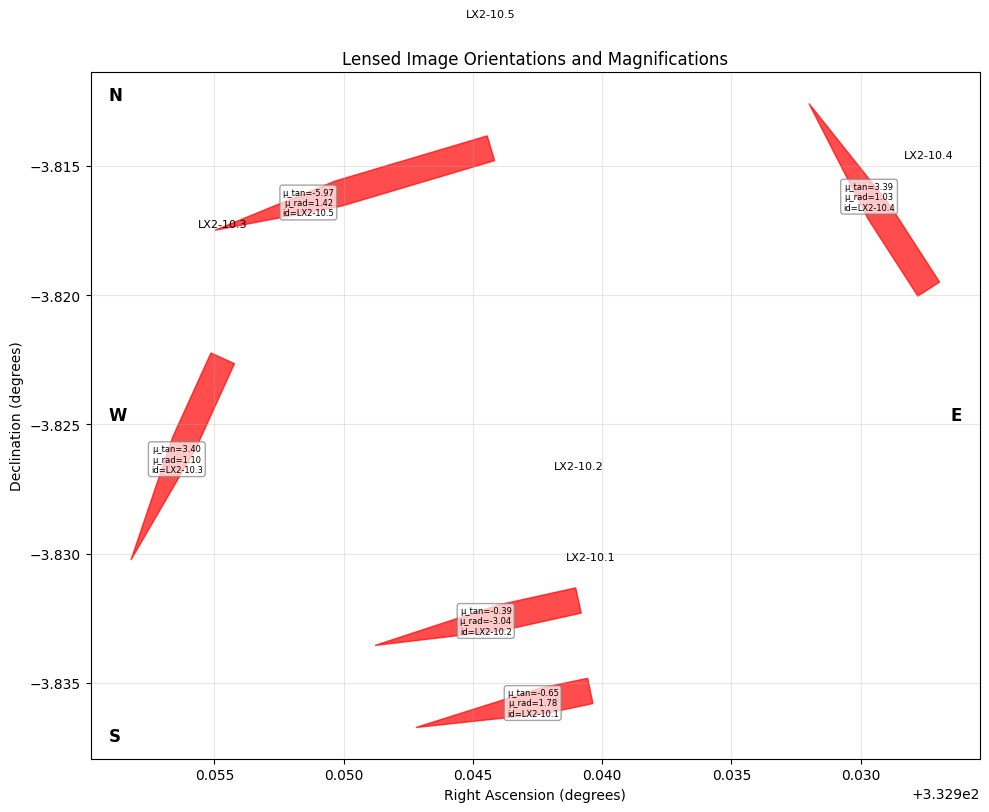

Lens Image Statistics:
Image LX2-10.3:
  Position: RA=332.954681, Dec=-3.822448
  Orientation: 155.54° (East of North)
  Magnifications: μ_tan=3.399, μ_rad=1.103
  Total μ: 3.749
------------------------------
Image LX2-10.5:
  Position: RA=332.944305, Dec=-3.814321
  Orientation: 106.54° (East of North)
  Magnifications: μ_tan=-5.974, μ_rad=1.419
  Total μ: 8.479
------------------------------
Image LX2-10.4:
  Position: RA=332.927368, Dec=-3.819770
  Orientation: 32.83° (East of North)
  Magnifications: μ_tan=3.393, μ_rad=1.035
  Total μ: 3.511
------------------------------
Image LX2-10.1:
  Position: RA=332.940460, Dec=-3.835316
  Orientation: 101.84° (East of North)
  Magnifications: μ_tan=-0.648, μ_rad=1.784
  Total μ: 1.156
------------------------------
Image LX2-10.2:
  Position: RA=332.940918, Dec=-3.831817
  Orientation: 102.45° (East of North)
  Magnifications: μ_tan=-0.389, μ_rad=-3.037
  Total μ: 1.181
------------------------------


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

# 假设你的表格已经加载为 newdf
# newdf = Table.read('your_file.fits')  # 或者用其他方式加载

def plot_lens_image_orientations(newdf):
    """
    绘制透镜像的拉伸方向箭头
    
    参数:
    newdf: astropy Table, 包含透镜像信息的表格
    """
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # 设置坐标轴方向：上北下南左东右西
    ax.set_aspect('equal')
    
    # 对于每个透镜像
    for i in range(len(newdf)):
        row = newdf.iloc[i]
        
        # 提取位置信息
        ra = row['ra']  # 赤经
        dec = row['dec']  # 赤纬
        ID = row['id']
        # 提取方向信息 (theta_best 是切向放大率的方向，东偏北，单位度)
        theta = row['theta_best']  # 方向角 (度，东偏北)
        
        # 提取放大率信息用于箭头长度
        mu_tan = row['mu_tan_best']  # 切向放大率分量
        mu_rad = row['mu_rad_best']  # 径向放大率分量
        
        # 计算总放大率用于箭头长度缩放
        total_mu = np.sqrt(mu_tan**2 + mu_rad**2)
        
        # 将角度从"东偏北"转换为数学坐标系中的角度
        # 天文学中: 0度=北, 90度=东, 180度=南, 270度=西
        # 数学坐标系中: 0度=东, 90度=北, 180度=西, 270度=南
        math_angle = 90 - theta  # 转换为数学坐标系角度
        
        # 确保角度在0-360度范围内
        math_angle = math_angle % 360
        
        # 将角度转换为弧度
        angle_rad = np.radians(math_angle)
        
        # 计算箭头的分量 (长度基于放大率缩放)
        arrow_length = 0.001 * total_mu  # 可根据需要调整缩放因子
        dx = arrow_length * np.cos(angle_rad)
        dy = arrow_length * np.sin(angle_rad)
        
        # 绘制箭头
        ax.arrow(ra, dec, dx, dy, 
                head_width=0.001, head_length=0.005, 
                fc='red', ec='red', alpha=0.7,
                label=f"{row['id']}" if i == 0 else "")
        
        # 标记像的ID
        ax.text(ra, dec + 0.005, row['id'], 
               fontsize=8, ha='center', va='bottom')
        
        # 在箭头旁边显示放大率信息
        ax.text(ra + dx*1.2, dec + dy*1.2, 
               f'μ_tan={mu_tan:.2f}\nμ_rad={mu_rad:.2f}\nid={ID}', 
               fontsize=6, ha='center', va='center',
               bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7))
    
    # 设置坐标轴标签
    ax.set_xlabel('Right Ascension (degrees)')
    ax.set_ylabel('Declination (degrees)')
    ax.set_title('Lensed Image Orientations and Magnifications')
    
    # 添加方向指示器
    ax.text(0.02, 0.98, 'N', transform=ax.transAxes, fontsize=12, 
           ha='left', va='top', weight='bold')
    ax.text(0.02, 0.02, 'S', transform=ax.transAxes, fontsize=12, 
           ha='left', va='bottom', weight='bold')
    ax.text(0.98, 0.5, 'E', transform=ax.transAxes, fontsize=12, 
           ha='right', va='center', weight='bold')
    ax.text(0.02, 0.5, 'W', transform=ax.transAxes, fontsize=12, 
           ha='left', va='center', weight='bold')
    
    # 添加网格
    ax.grid(True, alpha=0.3)
    
    # 反转x轴以符合天文惯例 (东在左，西在右)
    ax.invert_xaxis()
    
    plt.tight_layout()
    plt.show()

# 使用函数绘制
plot_lens_image_orientations(newdf)

# 可选：如果你想要更详细的统计信息
def print_lens_statistics(newdf):
    """打印透镜像的统计信息"""
    print("Lens Image Statistics:")
    print("=" * 50)
    for i in range(len(newdf)):
        row = newdf.iloc[i]
        print(f"Image {row['id']}:")
        print(f"  Position: RA={row['ra']:.6f}, Dec={row['dec']:.6f}")
        print(f"  Orientation: {row['theta_best']:.2f}° (East of North)")
        print(f"  Magnifications: μ_tan={row['mu_tan_best']:.3f}, μ_rad={row['mu_rad_best']:.3f}")
        print(f"  Total μ: {row['mu_best']:.3f}")
        print("-" * 30)

# 打印统计信息
print_lens_statistics(newdf)

### Output
columns in **newdf** data frame: 

- **id,ra,dec,z**: input data used for computing magnifications
- **mu_best**: best-fit magnifications
- **mu_tan_best**: best-fit magnification component $\mu_{\rm tan}$
- **mu_rad_best**: best-fit magnification component $\mu_{\rm rad}$
- **theta_best**: best-fit orientation of mu_tan magnification (in degrees, east of north)
- **deflect_x_best**: best-fit deflection angle in x direction in arcsec
- **deflect_y_best**: best-fit deflection angle in y direction in arcsec
- **ra_source_best**: source plane position, derived with deflect_x_best
- **dec_source_best**: source plane pos”ition, derived with deflect_y_best

If lens model provides Bayesian sample maps, newdf also contains percentiles for each of the lensing quantities above. In the additional columns the suffix **best** (from above) is replaced with **16**, **50** or **84** for the 16th, 50th or 84th percentile, respectively. For instance, magnification percentiles are given in **mu_16**, **mu_50** and **mu_84** columns.

In [51]:
source_plane = 



SyntaxError: invalid syntax (582971966.py, line 1)

NameError: name 'caustic_ra1' is not defined

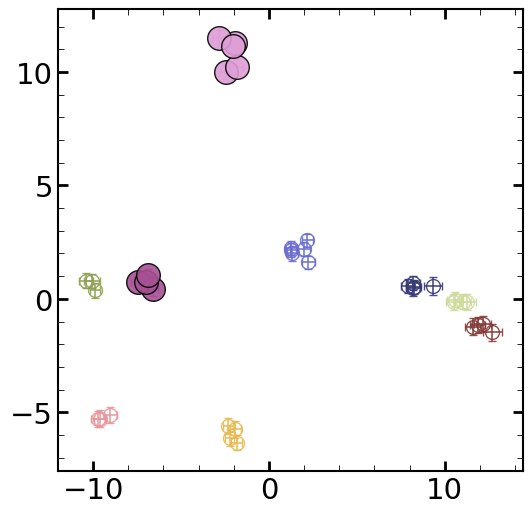

In [65]:
targetlist = ['4.',  '11.', '16.', '17.', '18.', '22.', '37.', '9.', '10.',]
import matplotlib.pyplot as plt
import numpy as np

source_plane = Table.read(f"/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/lensing_model/RXCJ2211/full_output.csv")
names = source_plane['id']
# 调整配色方案
colors = plt.cm.tab20b(np.linspace(0, 1, len(targetlist)))

plt.figure(figsize=(6, 6))

for target, color in zip(targetlist, colors):
    # namemask = [i.startswith(target) for i in names]
    namemask = [i > float(target) and i < float(target) + 1 for i in names]
    dfsub = source_plane[namemask]

    rabest =  (dfsub['ra_source_best'] - 332.9413169) * 3600
    decbest = (dfsub['dec_source_best'] - -3.8290195) * 3600
    raerr = (dfsub['ra_source_84'] - dfsub['ra_source_16']) / 2 * 3600
    decerr = (dfsub['dec_source_84'] - dfsub['dec_source_16']) / 2 * 3600

    # 判断是否为 LX1 或 LX2
    if target in ['9.', '10.']:
        mfc = color  # 实心
        mec = 'k'
        zorder = 3
        lw = 1.2
        ms= 17
        ID_pre = ''
    else:
        mfc = 'none'  # 空心
        mec = color
        zorder = 2
        lw = 1.2
        ms = 10
        ID_pre = 'ID'

    plt.errorbar(
        rabest, decbest,
        xerr=raerr, yerr=decerr,
        fmt='o', ms=ms, capsize=3,
        mfc=mfc, mec=mec, color=color, lw=lw,
        label=ID_pre + target.replace('9.', 'RX1').replace('10.', 'RX2').replace('.', ''), alpha=0.9, zorder=zorder
    )

plt.scatter(caustic_ra1, caustic_dec1, color = 'gray',s = 0.05)
# plt.scatter(caustic_ra2, caustic_dec2, s = 0.1)
plt.axhline(0, color='gray', ls='--', lw=1)
plt.axvline(0, color='gray', ls='--', lw=1)
plt.xlabel(r'$\Delta$RA (arcsec)', fontsize=20)
plt.ylabel(r'$\Delta$Dec (arcsec)', fontsize=20)
plt.legend(loc=0, fontsize=13, ncols=1)
plt.gca().invert_xaxis()
plt.tight_layout()
plt.axis('equal')   # ✅ 保持XY比例尺相同
plt.text(-0.15, 0.98, f'A', color='k', fontsize=23, transform=plt.gca().transAxes, ha='left', va='top', weight='bold')
plt.savefig('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/figure/' + 'z4sourcelplane_pos.pdf', dpi=200, bbox_inches='tight')
# plt.show()

In [67]:
#OPTIONAL
#save the output as a fits catalog
path_output=f"/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/lensing_model/RXCJ2211/full_output_v91_RX1_z6.csv"
#save output as fits table
Table.from_pandas(newdf).write(path_output, overwrite=True)


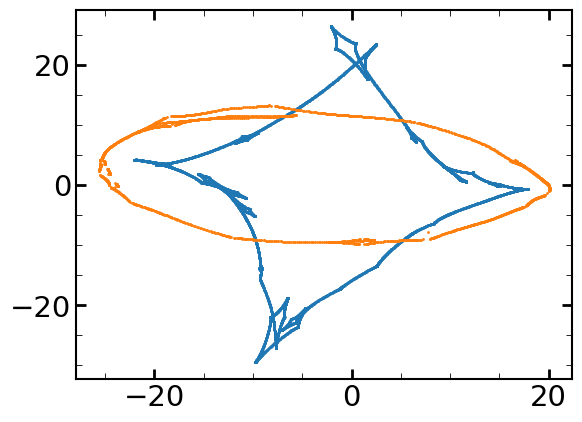

In [14]:
caustic1 = Table.read(f"/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/lensing_model/RXCJ2211/caustic_1.csv")
caustic_ra1 =  (caustic1['ra_source_best'] - 332.9413169) * 3600
caustic_dec1 = (caustic1['dec_source_best'] - -3.8290195) * 3600

caustic2 = Table.read(f"/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/lensing_model/RXCJ2211/caustic_2.csv")
caustic_ra2 =  (caustic2['ra_source_best'] - 332.9413169) * 3600
caustic_dec2 = (caustic2['dec_source_best'] - -3.8290195) * 3600

plt.scatter(caustic_ra1, caustic_dec1, s = 1)
plt.scatter(caustic_ra2, caustic_dec2, s = 1)

In [53]:
# newdf.sort('id')
names = newdf['id']
target = 9
namemask = [i > float(target) and i < float(target) + 1 for i in names]
newdf[namemask][['id','ra','dec', 'mu_best', 'mu_16', 'mu_84']]

,id,ra,dec,mu_best,mu_16,mu_84
0,9.2,332.924408,-3.827680,2.245698,2.135230,2.271717
1,9.4,332.944366,-3.819110,3.024980,2.837740,3.107617
2,9.1,332.953857,-3.832068,3.653383,3.462878,3.743334
3,9.3,332.940582,-3.840669,2.197693,2.078804,2.233229


In [67]:
# 假设 newdf 已经存在
target = 9
names = newdf['id']

# 选出满足条件的行
namemask = [(i > float(target)) and (i < float(target) + 1) for i in names]
selected = newdf[namemask]#[['id', 'mu_best','mu_50', 'mu_16', 'mu_84']]

# 输出 LaTeX 格式
for idx, row in selected.iterrows():
    id_val = row['id']
    mu_best = row['mu_tan_50']
    mu_low = mu_best - row['mu_tan_16']
    mu_up = row['mu_tan_84'] - mu_best
    latex_str = f"{id_val}: ${mu_best:.2f}^{{+{mu_up:.2f}}}_{{-{mu_low:.2f}}}$"
    print(latex_str)

9.2: $2.15^{+0.05}_{-0.04}$
9.4: $-1.88^{+0.07}_{-0.06}$
9.1: $3.25^{+0.12}_{-0.08}$
9.3: $-1.70^{+0.05}_{-0.04}$


In [56]:
row['mu_rad_84']

-2.6615012203547095

In [57]:
mu_best

-3.014959867757599

In [58]:
row['mu_rad_16']

-2.981443397461665

In [62]:
row['mu_rad_50']

-2.8266946657818965